In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

In [2]:
def parse_model_details(name):
    """
    Parses model name to extract:
    1. Adapter Type (e.g., uiortholora)
    2. Configuration (e.g., s1024_v32, r3)
    3. Learning Rate
    """
    # 1. Extract LR
    lr_match = re.search(r'_lr([0-9e\-\.]+)', name)
    try:
        lr = float(lr_match.group(1).rstrip('_')) if lr_match else None
    except ValueError:
        lr = None

    # 2. Determine Type & Config
    adapter_type = 'unknown'
    config = 'default'

    if '_lora_' in name and '_uiortholora_' not in name and '_randlora_' not in name:
        adapter_type = 'LORA'
        match = re.search(r'lora_r(\d+)', name)
        if match:
            config = f"r{match.group(1)}"

    elif '_uiortholora_' in name:
        adapter_type = 'UIORTHOLORA'
        # Look for patterns like s1024_v32
        match = re.search(r's(\d+)_v(\d+)', name)
        if match:
            config = f"s{match.group(1)}_v{match.group(2)}"
        else:
            # Fallback if pattern differs
            match_s = re.search(r'_s(\d+)', name)
            match_v = re.search(r'_v(\d+)', name)
            s_val = match_s.group(1) if match_s else "?"
            v_val = match_v.group(1) if match_v else "?"
            config = f"s{s_val}_v{v_val}"

    elif '_vera_' in name:
        adapter_type = 'VERA'
        match = re.search(r'vera_r(\d+)', name)
        if match:
            config = f"r{match.group(1)}"

    elif '_randlora_' in name:
        adapter_type = 'RANDLORA'
        match = re.search(r'randlora_r(\d+)', name)
        if match:
            config = f"r{match.group(1)}"
            
    return adapter_type, config, lr

def plot_detailed_accuracy(df, accuracy_col='accuracy', 
                           group_col='display_label', lr_col='lr', 
                           ylim=None):
    """
    Plots grouped bar charts where the X-axis is the specific Adapter Configuration.
    """
    
    # Ensure model_name exists for splitting plots
    if 'model_name' not in df.columns:
        df['model_name'] = "Model Results"

    unique_models = df['model_name'].unique()

    for model_name in unique_models:
        sub_df = df[df['model_name'] == model_name].copy()
        sub_df = sub_df.dropna(subset=[group_col, lr_col, accuracy_col])
        
        if sub_df.empty:
            continue

        # Get unique configs and LRs
        # Sort configs alphabetically or by some custom logic if needed
        configs = sorted(sub_df[group_col].unique())
        lrs = sorted(sub_df[lr_col].unique())
        
        # --- Color Setup (Viridis Reversed) ---
        cmap = cm.get_cmap('viridis_r')
        norm = mcolors.Normalize(vmin=0, vmax=len(lrs)-1)
        lr_color_map = {lr: cmap(norm(i)) for i, lr in enumerate(lrs)}
        
        fig, ax = plt.subplots(figsize=(14, 8)) # Wider figure for more bars
        
        n_configs = len(configs)
        n_lrs = len(lrs)
        
        # Adjust bar widths to fit everything
        # If there are many configs, we might need thinner bars
        total_group_width = 0.85
        bar_width = total_group_width / n_lrs
        x = np.arange(n_configs)
        
        for i, lr in enumerate(lrs):
            accs = []
            for conf in configs:
                # Select data for this specific config + LR
                row = sub_df[(sub_df[group_col] == conf) & (sub_df[lr_col] == lr)]
                
                if not row.empty:
                    accs.append(row[accuracy_col].mean())
                else:
                    accs.append(0) # or np.nan to leave gap
            
            offset = (i - n_lrs / 2 + 0.5) * bar_width
            lr_label = f'{lr:.0e}'.replace('e-0', 'e-')
            
            ax.bar(x + offset, accs, bar_width, label=f'LR={lr_label}',
                   color=lr_color_map[lr], edgecolor='black', linewidth=0.5)
        
        # Formatting
        ax.set_ylabel("Accuracy", fontsize=12)
        display_title = str(model_name).split('/')[-1]
        ax.set_title(f"{display_title}: Accuracy by Detailed Configuration", fontsize=15, fontweight='bold')
        
        ax.set_xticks(x)
        # Rotate labels because configs like "UIORTHOLORA s1024_v32" are long
        ax.set_xticklabels(configs, rotation=45, ha='right', fontsize=10, fontweight='medium')
        
        ax.legend(title="Learning Rate", title_fontsize=10, fontsize=9, 
                  loc='upper left', bbox_to_anchor=(1, 1)) # Legend outside to save space
        
        ax.grid(True, alpha=0.2, axis='y')
        
        if ylim:
            ax.set_ylim(ylim)
        else:
            ax.set_ylim(0, sub_df[accuracy_col].max() * 1.15)

        plt.tight_layout()
        plt.show()

/tmp/ipykernel_3210292/3739411447.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis_r')


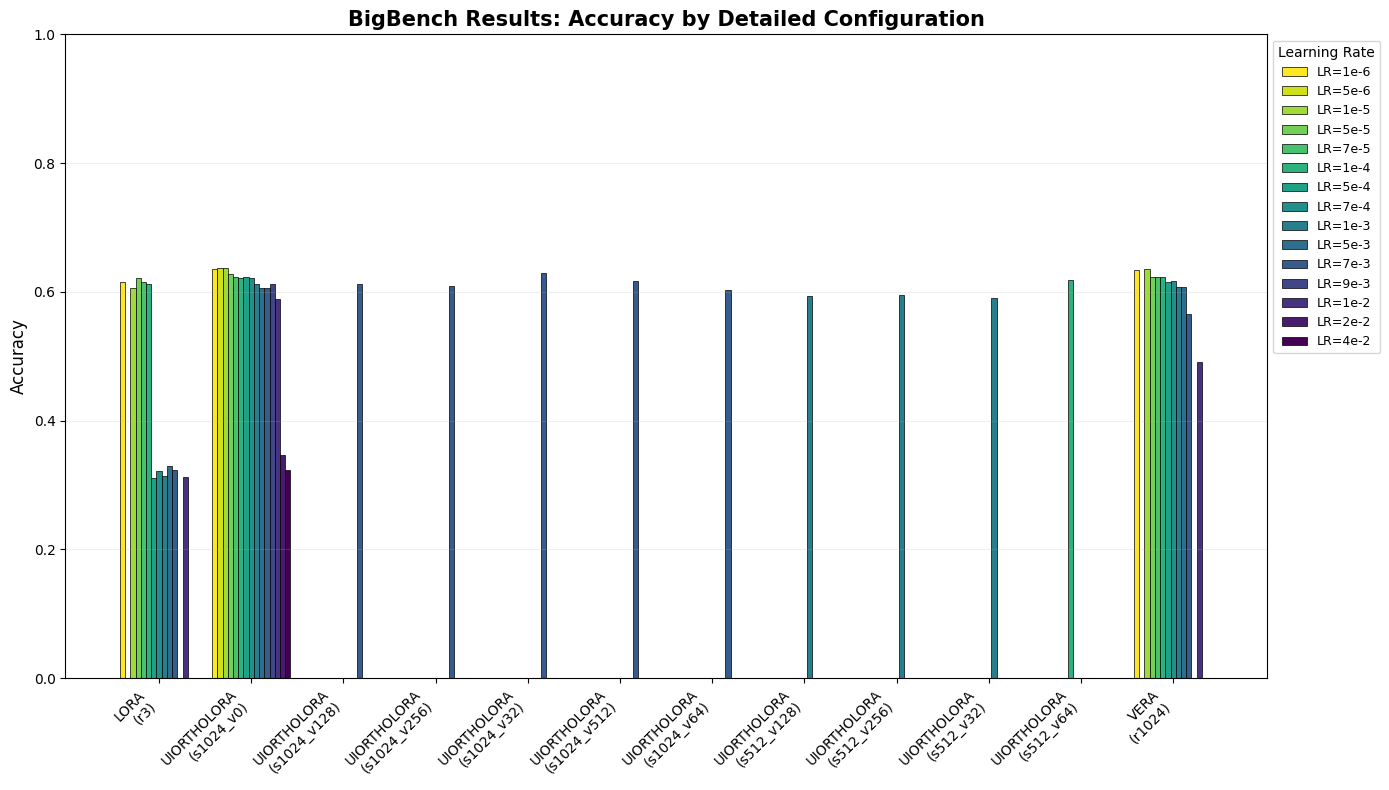

In [3]:
# ============================================================================
# CELL: Detailed BigBench Visualization
# ============================================================================

bigbench_csv = "../results/bigbench/summary.csv"
df_bb = pd.read_csv(bigbench_csv)

# 1. Apply Detailed Parsing
parsed_data = df_bb['model_path'].apply(lambda x: pd.Series(parse_model_details(x)))
df_bb['adapter_type'] = parsed_data[0]
df_bb['config'] = parsed_data[1]
df_bb['lr'] = parsed_data[2]

# 2. Create a "Display Label" that combines Type and Config
# Example result: "LORA\n(r3)" or "UIORTHOLORA\n(s1024_v32)"
df_bb['display_label'] = df_bb.apply(
    lambda row: f"{row['adapter_type']}\n({row['config']})", axis=1
)

# 3. Handle model naming if needed
if 'model_name' not in df_bb.columns:
    df_bb['model_name'] = "BigBench Results"

# 4. Plot
plot_detailed_accuracy(
    df_bb, 
    accuracy_col='mean_accuracy',
    group_col='display_label',  # Use our new detailed label
    lr_col='lr',
    ylim=(0, 1.0)
)

In [4]:
def parse_model_name(name):
    """Extract adapter type and learning rate from model name."""
    # Extract adapter type
    if '_lora_' in name and 'ortho' not in name:
        adapter = 'lora'
    elif 'uiortholora' in name:
        adapter = 'uiortholora'
    elif 'vera' in name:
        adapter = 'vera'
    elif 'randlora' in name:
        adapter = 'randlora'
    else:
        adapter = 'unknown'
    
    # Extract learning rate (last part after _lr)
    lr_str = name.split('_lr')[-1]
    lr = float(lr_str)
    
    return adapter, lr


def plot_accuracy_by_adapter_lr(df, accuracy_col, title, output_path=None, 
                                 adapter_col='adapter', lr_col='lr', 
                                 stderr_col=None, ylim=None):
    """
    Grouped bar chart: Accuracy by Adapter, grouped by Learning Rate.
    
    Args:
        df: DataFrame with adapter, lr, and accuracy columns
        accuracy_col: Column name for accuracy values
        title: Plot title
        output_path: Optional path to save figure
        adapter_col: Column name for adapter type
        lr_col: Column name for learning rate
        stderr_col: Optional column name for error bars
        ylim: Optional tuple (ymin, ymax) for y-axis limits
    """
    adapters = sorted(df[adapter_col].unique())
    lrs = sorted(df[lr_col].unique())
    
    # LR colors
    lr_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(lrs)))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    n_adapters = len(adapters)
    n_lrs = len(lrs)
    bar_width = 0.8 / n_lrs
    x = np.arange(n_adapters)
    
    for i, lr in enumerate(lrs):
        accs = []
        errs = []
        for adapter in adapters:
            row = df[(df[adapter_col] == adapter) & (df[lr_col] == lr)]
            if len(row) > 0:
                accs.append(row[accuracy_col].values[0])
                if stderr_col and stderr_col in df.columns:
                    errs.append(row[stderr_col].values[0])
                else:
                    errs.append(0)
            else:
                accs.append(0)
                errs.append(0)
        
        offset = (i - n_lrs / 2 + 0.5) * bar_width
        
        if stderr_col and stderr_col in df.columns:
            ax.bar(x + offset, accs, bar_width, label=f'LR={lr:.0e}',
                   color=lr_colors[i], edgecolor='black', linewidth=0.5,
                   yerr=errs, capsize=3)
        else:
            ax.bar(x + offset, accs, bar_width, label=f'LR={lr:.0e}',
                   color=lr_colors[i], edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel("Adapter Type", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(adapters, fontsize=11)
    ax.legend(title="Learning Rate", loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    if ylim:
        ax.set_ylim(ylim)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    return fig, ax

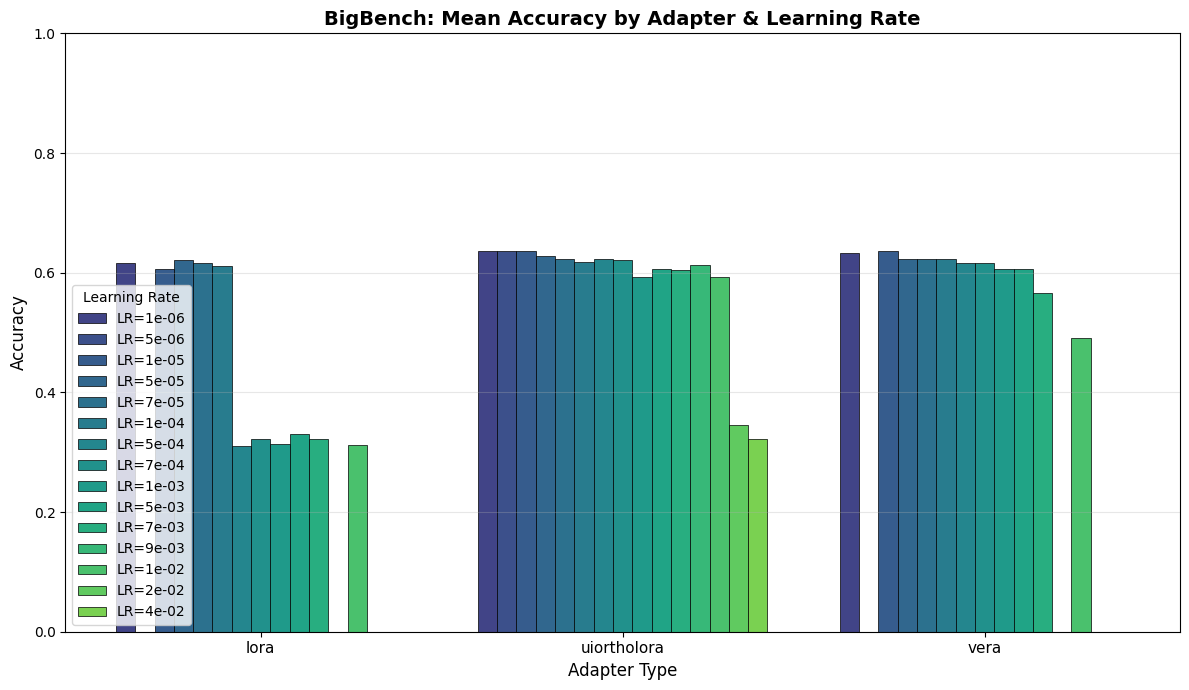

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'BigBench: Mean Accuracy by Adapter & Learning Rate'}, xlabel='Adapter Type', ylabel='Accuracy'>)

In [5]:
# ============================================================================
# CELL 1: BigBench Visualization
# ============================================================================

bigbench_csv = "../results/bigbench/summary.csv"
df_bb = pd.read_csv(bigbench_csv)

# Parse adapter and LR from model_path column
df_bb[['adapter', 'lr']] = df_bb['model_path'].apply(lambda x: pd.Series(parse_model_name(x)))

plot_accuracy_by_adapter_lr(
    df_bb, 
    accuracy_col='mean_accuracy',
    title='BigBench: Mean Accuracy by Adapter & Learning Rate',
    output_path='bigbench_accuracy.png',
    ylim=(0, 1)
)

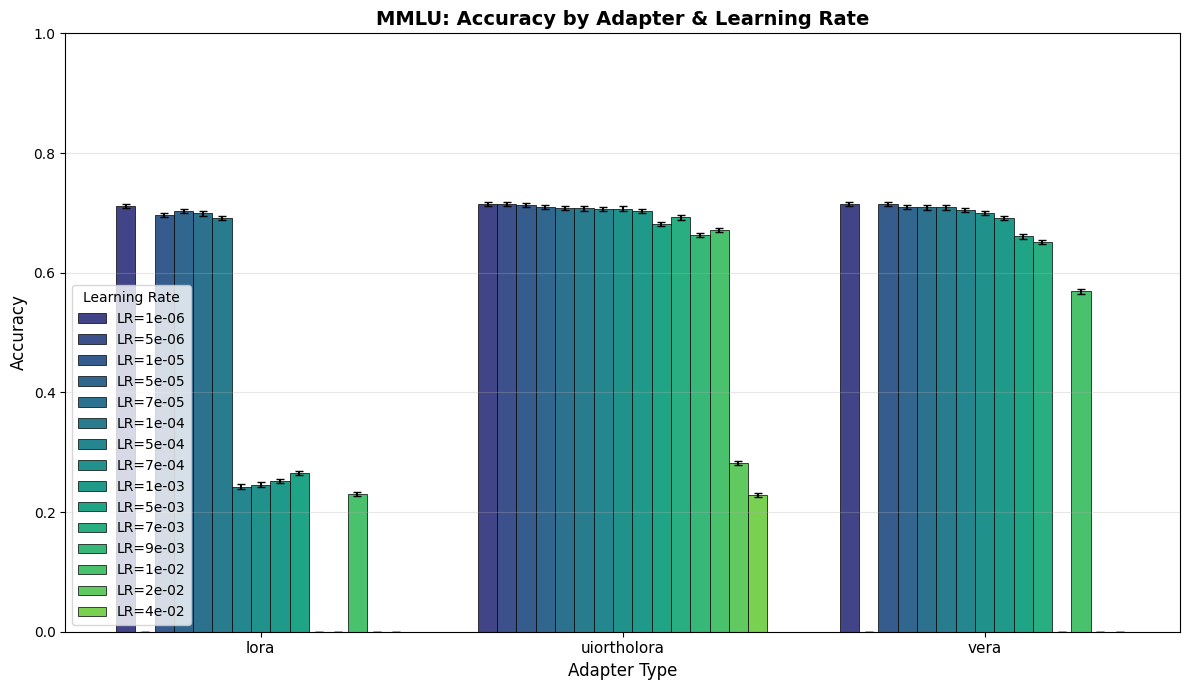

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'MMLU: Accuracy by Adapter & Learning Rate'}, xlabel='Adapter Type', ylabel='Accuracy'>)

In [6]:
# ============================================================================
# CELL 2: MMLU Visualization
# ============================================================================
# MMLU data (paste your CSV or load from file)
path = "../results/mmlu/mmlu_summary.csv"
df_mmlu = pd.read_csv(path)

df_mmlu[['adapter', 'lr']] = df_mmlu['model_name'].apply(lambda x: pd.Series(parse_model_name(x)))

plot_accuracy_by_adapter_lr(
    df_mmlu, 
    accuracy_col='mmlu_acc',
    title='MMLU: Accuracy by Adapter & Learning Rate',
    output_path='mmlu_accuracy.png',
    stderr_col='mmlu_acc_stderr',
    ylim=(0, 1)
)